# ML Config — Significant Taxa + Clinical Metadata

Loads the master feature table built by `ml_00_prepare_feature_table.ipynb`
and the shared pipeline functions in `ml_pipeline_utils.py`. This notebook
only selects which columns to use (Step 3) - all data cleaning happened once,
upstream, in the prep notebook.

**Keep `ml_pipeline_utils.py` in the same folder as this notebook**, or add
its folder to `sys.path` before importing.



In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# sys.path.append("/path/to/folder/containing/ml_pipeline_utils.py")  # uncomment and edit if needed
from ml_pipeline_utils import (
    RANDOM_STATE, check_platform_leakage, run_hyperparameter_search, run_loso_evaluation_with_lasso,
    fit_final_lasso_selector, run_loso_evaluation, plot_confusion_matrix, run_shap_analysis, save_artifacts
)

from sklearn.preprocessing import StandardScaler, LabelEncoder


## Step 1 - Load the master feature table and column lists

In [2]:
# ---- EDIT THESE PATHS ----
# FEATURE_TABLE_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/processed/ml_feature_table")
# OUTPUT_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/results/ml_config_sig_taxa_only")
FEATURE_TABLE_DIR = Path("ml_feature_table")
OUTPUT_DIR = Path("ml_config3_shared_taxa_clinical_lasso")
# ---------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(FEATURE_TABLE_DIR / "ml_master_feature_table.csv", index_col=0)

def load_list(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

all_taxa_columns         = load_list(FEATURE_TABLE_DIR / "all_taxa_columns.txt")
significant_taxa_columns = load_list(FEATURE_TABLE_DIR / "significant_taxa_columns.txt")
clinical_columns         = load_list(FEATURE_TABLE_DIR / "clinical_columns.txt")
pathway_columns          = load_list(FEATURE_TABLE_DIR / "pathway_columns.txt")

print("Master table:", master.shape)
print(master["disease_group"].value_counts())


Master table: (1831, 751)
disease_group
HC    756
PD    752
AD    323
Name: count, dtype: int64


## Step 2 - Confirm the master table is what you expect

In [3]:
assert master[all_taxa_columns].isna().sum().sum() == 0, "Unexpected NaNs in taxa columns"
assert master[clinical_columns].isna().sum().sum() == 0, "Unexpected NaNs in clinical columns"
assert master[pathway_columns].isna().sum().sum() == 0, "Unexpected NaNs in pathway columns"
print("No unexpected NaNs found in the feature blocks - good to proceed.")


No unexpected NaNs found in the feature blocks - good to proceed.


## Step 3 - Select this notebook's feature set

Significant-genera union plus the cross-cutting clinical block (age/sex/BMI, MMSE/UPDRS_III excluded by default in the prep notebook).


In [4]:
feature_cols = significant_taxa_columns + clinical_columns
print(f"Using {len(significant_taxa_columns)} taxa + {len(clinical_columns)} clinical features.")

Using 43 taxa + 6 clinical features.


In [5]:
# building feature cols for only shared taxa: 
shared_taxa = ["g__Enterococcus", "g__Roseburia", "g__Haemophilus", "g__Clostridium", "g__Faecalibacterium", "g__Eisenbergiella", "g__Lachnospira"]
# Match either direct column names, 'taxon__<name>', or stripped genus names
feature_cols = []
for taxon in shared_taxa:
    clean_name = taxon.replace("g__", "")
    matched = [
        col for col in all_taxa_columns 
        if col == taxon 
        or col == f"taxon__{taxon}" 
        or col == f"taxon__{clean_name}" 
        or col == clean_name
    ]
    if matched:
        feature_cols.append(matched[0])
    else:
        print(f"WARNING: Taxon '{taxon}' not found in all_taxa_columns!")

print(f"Using {len(feature_cols)} shared taxa features: {feature_cols}")
assert len(feature_cols) == len(shared_taxa), f"Expected {len(shared_taxa)} features, but matched {len(feature_cols)}."

feature_cols = feature_cols + clinical_columns
print(f"Using {len(shared_taxa)} taxa + {len(clinical_columns)} clinical features.")

Using 7 shared taxa features: ['taxon__g__Enterococcus', 'taxon__g__Roseburia', 'taxon__g__Haemophilus', 'taxon__g__Clostridium', 'taxon__g__Faecalibacterium', 'taxon__g__Eisenbergiella', 'taxon__g__Lachnospira']
Using 7 taxa + 6 clinical features.


## Step 4 - Platform-leakage sanity check (diagnostic, not the real model)

Checks whether this exact feature set can trivially separate PD vs AD before
the real 3-class model runs. Given this project's documented platform
confound (100% shotgun vs 100% 16S), a near-perfect AUC here is a red flag,
not a result to celebrate.


In [6]:
check_platform_leakage(master, feature_cols)


PD-vs-AD study-grouped 5-fold AUC using 13 features: 0.951 +/- 0.061


(np.float64(0.9509926432111306), np.float64(0.06091716563611705))

## Step 5 - Prepare X, y, groups

In [7]:
label_encoder = LabelEncoder()
master["y"] = label_encoder.fit_transform(master["disease_group"])
print("Class encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X = master[feature_cols].values
y = master["y"].values
groups = master["study_id"].values

print(f"Final feature count: {len(feature_cols)}")


Class encoding: {'AD': np.int64(0), 'HC': np.int64(1), 'PD': np.int64(2)}
Final feature count: 13


Initial feature count: 13
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV f1_macro: 0.5490833107012236

Fold 0 (held out bedarf2017)
LASSO selected 12/13 features
n=59, classes_present=2/3, Accuracy=0.186, F1_macro=0.138, AUC=NA

Fold 1 (held out binyinli2019)
LASSO selected 13/13 features
n=60, classes_present=2/3, Accuracy=0.533, F1_macro=0.332, AUC=NA

Fold 2 (held out boktor2023_rumc)
LASSO selected 13/13 features
n=114, classes_present=2/3, Accuracy=0.860, F1_macro=0.572, AUC=NA

Fold 3 (held out boktor2023_tbc)
LASSO selected 13/13 features
n=113, classes_present=2/3, Accuracy=0.619, F1_macro=0.410, AUC=NA

Fold 4 (held out cirstea2022)
LASSO selected 13/13 features
n=98, classes_present=2/3, Accuracy=0.265, F1_macro=0.197, AUC=NA

Fold 5 (held out clasen2024)
LASSO selected 13/13 features
n=126, classes_present=2/3, Accuracy=0.810, F1_macro=0.407, AUC=NA

Fold 6 (held out ling2021)
L

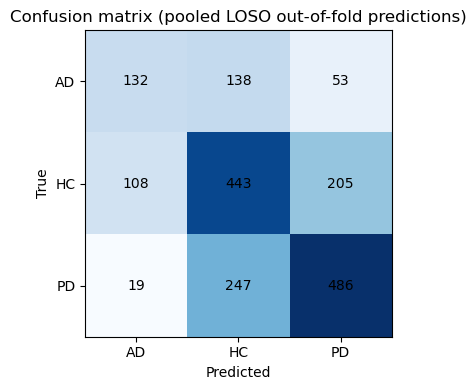

              precision    recall  f1-score   support

          AD       0.51      0.41      0.45       323
          HC       0.54      0.59      0.56       756
          PD       0.65      0.65      0.65       752

    accuracy                           0.58      1831
   macro avg       0.57      0.55      0.55      1831
weighted avg       0.58      0.58      0.58      1831


Study-level LOSO metrics:


,held_out_study,n_test_samples,n_classes_present,n_selected_features,selected_features,accuracy,f1_macro,auc,actual_AD,actual_HC,actual_PD,predicted_AD,predicted_HC,predicted_PD
11,yamashiro2024,37,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.054054,0.060606,NaN,18,19,0,0,3,34
0,bedarf2017,59,2,12,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.186441,0.138365,NaN,0,28,31,34,25,0
4,cirstea2022,98,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.265306,0.196970,NaN,45,53,0,0,35,63
9,ueda2021,7,1,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.428571,0.200000,NaN,7,0,0,3,4,0
7,liu2019,61,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.508197,0.327778,NaN,33,28,0,39,22,0
6,ling2021,171,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.514620,0.328073,NaN,100,71,0,35,136,0
1,binyinli2019,60,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.533333,0.331738,NaN,30,30,0,46,14,0
12,yildirim2022,97,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.546392,0.363972,NaN,47,50,0,47,50,0
10,wallen2022,724,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.580110,0.377588,NaN,0,234,490,3,355,366
5,clasen2024,126,2,13,taxon__g__Enterococcus;taxon__g__Roseburia;tax...,0.809524,0.407407,NaN,0,22,104,0,14,112



Final full-data LASSO selection:
13 / 13 features retained
Generating SHAP beeswarm for class: AD


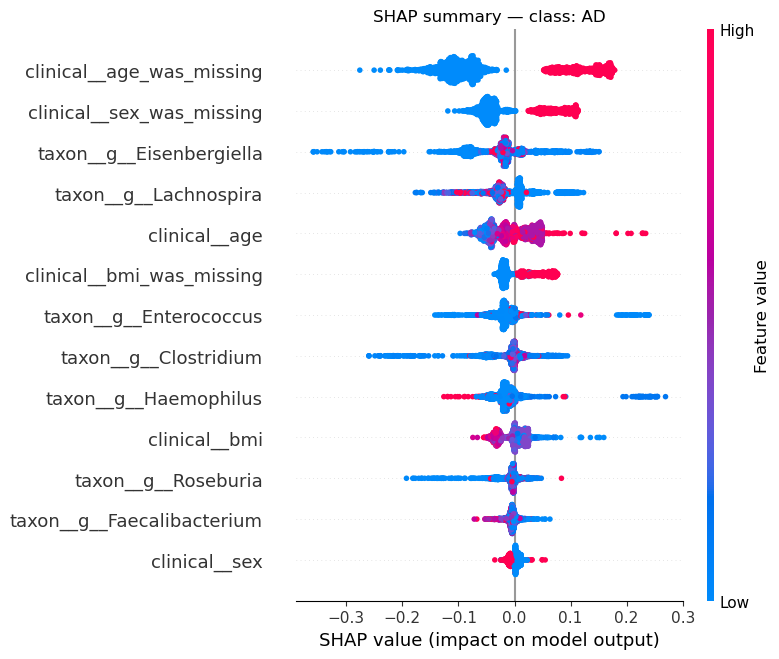

Generating SHAP beeswarm for class: HC


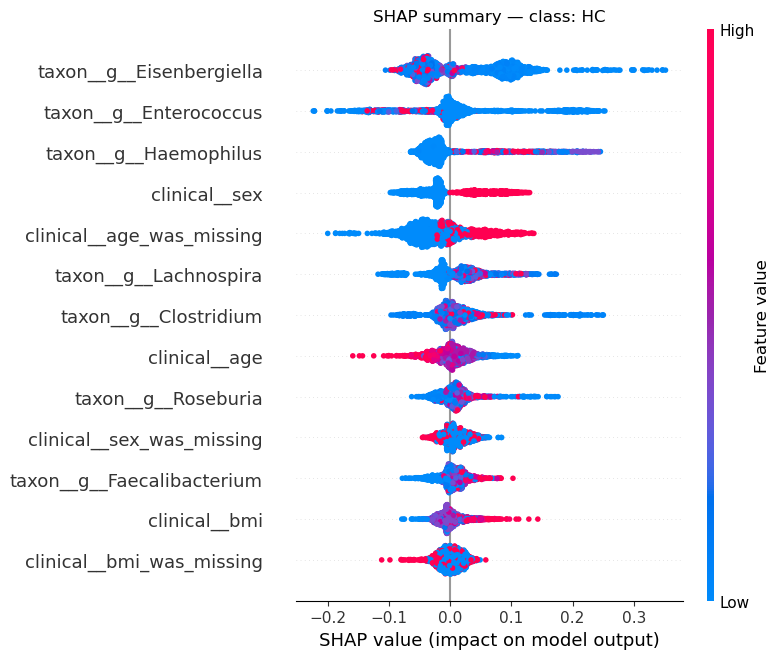

Generating SHAP beeswarm for class: PD


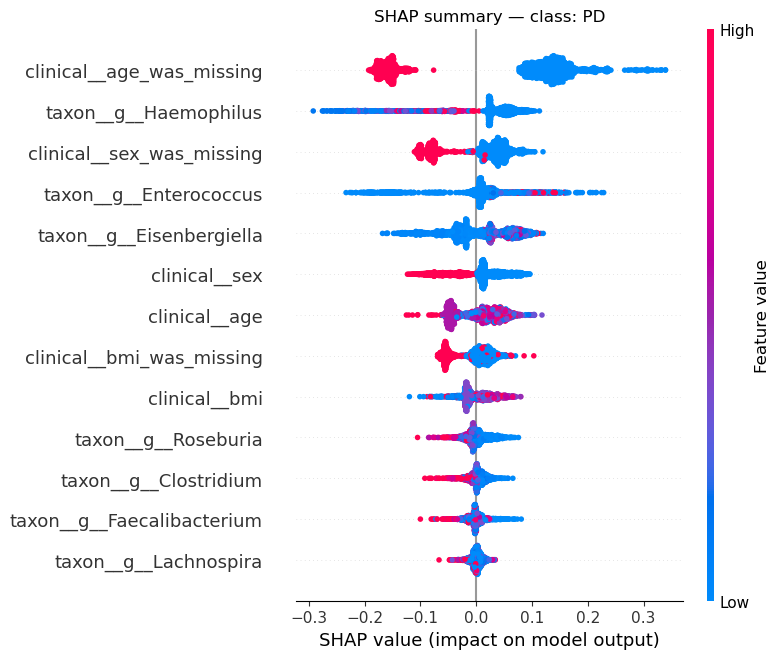

Saved model, scaler, label encoder, and feature list to: ml_config3_shared_taxa_clinical_lasso


NameError: name 'scaler' is not defined

<Figure size 640x480 with 0 Axes>

In [8]:
print(f"Initial feature count: {len(feature_cols)}")

# ==========================================================
# GLOBAL HYPERPARAMETER SEARCH
#
# This produces one parameter set for the final exported model.
# ==========================================================
grid = run_hyperparameter_search(X,y,groups,)

# ==========================================================
# LOSO + FOLD-WISE LASSO
# ==========================================================
(
    loso_df,
    all_y_true,
    all_y_pred,
    all_y_proba,
) = run_loso_evaluation_with_lasso(
    X=X,
    y=y,
    groups=groups,
    feature_cols=feature_cols,
    best_params=grid.best_params_,
    label_encoder=label_encoder,
    output_dir=OUTPUT_DIR,
    min_features=1,
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================
cm_df = plot_confusion_matrix(all_y_true,all_y_pred,label_encoder,OUTPUT_DIR,)

# ==========================================================
# STUDY-LEVEL LOSO TABLE
# ==========================================================
print("\nStudy-level LOSO metrics:")
display(loso_df.sort_values("f1_macro"))

# ==========================================================
# FINAL FULL-DATA LASSO
# This defines ONE final feature set for:
#   - final RF model
#   - SHAP
#   - exported artifacts
# ==========================================================
(
    final_selected_indices,
    final_selected_features,
    final_lasso_scaler,
    final_lasso_model,
) = fit_final_lasso_selector(
    X=X,
    y=y,
    feature_cols=feature_cols,
    min_features=1,
)

# ==========================================================
# FINAL RANDOM FOREST
# ==========================================================
from sklearn.ensemble import RandomForestClassifier
X_final = X[:,final_selected_indices]
final_model = RandomForestClassifier(**grid.best_params_,class_weight="balanced",random_state=RANDOM_STATE,n_jobs=-1,)
final_model.fit(X_final,y,)

# ==========================================================
# SHAP
# ==========================================================
shap_values = run_shap_analysis(final_model,X_final,final_selected_features,label_encoder,OUTPUT_DIR,max_display=30,)

# ==========================================================
# SAVE FINAL ARTIFACTS
# RF does not need a scaler.
# The LASSO scaler/model are saved separately below.
# ==========================================================
save_artifacts(final_model,None,label_encoder,final_selected_features,OUTPUT_DIR,)

import joblib
joblib.dump(final_lasso_scaler,OUTPUT_DIR / "lasso_scaler.joblib")
joblib.dump(final_lasso_model,OUTPUT_DIR / "lasso_selector.joblib")
if scaler is not None:joblib.dump(scaler,output_dir / "scaler.joblib")
print("\nFinal LASSO-selected features:")
print(final_selected_features)

## Step 9 - Final model + SHAP (interpretation only, not a performance claim)

`final_model` is fit on all data and used only for SHAP - performance metrics
come from the LOSO loop above.


Generating SHAP beeswarm for class: AD


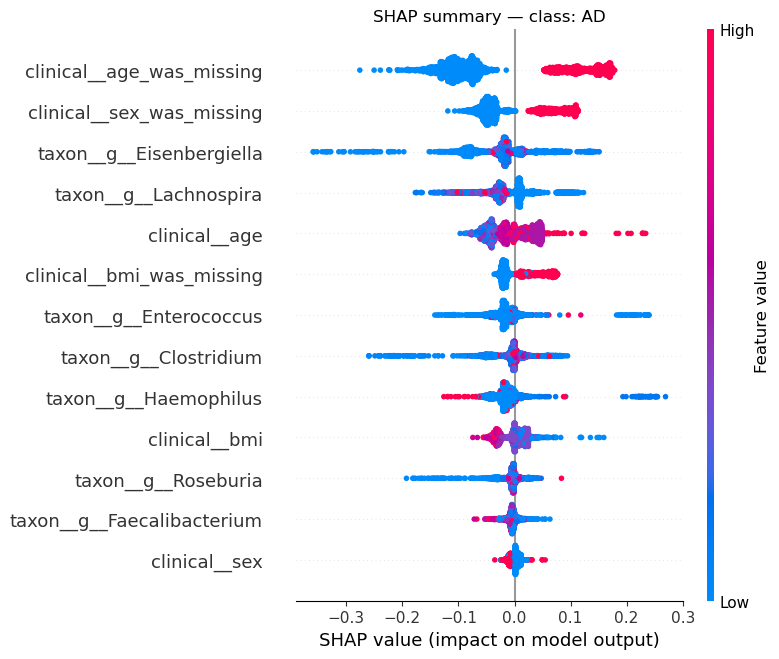

Generating SHAP beeswarm for class: HC


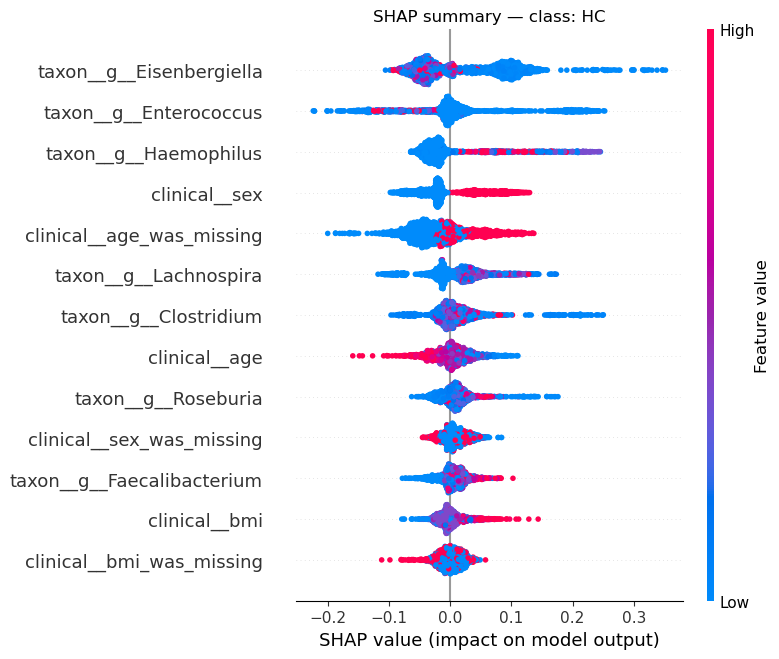

Generating SHAP beeswarm for class: PD


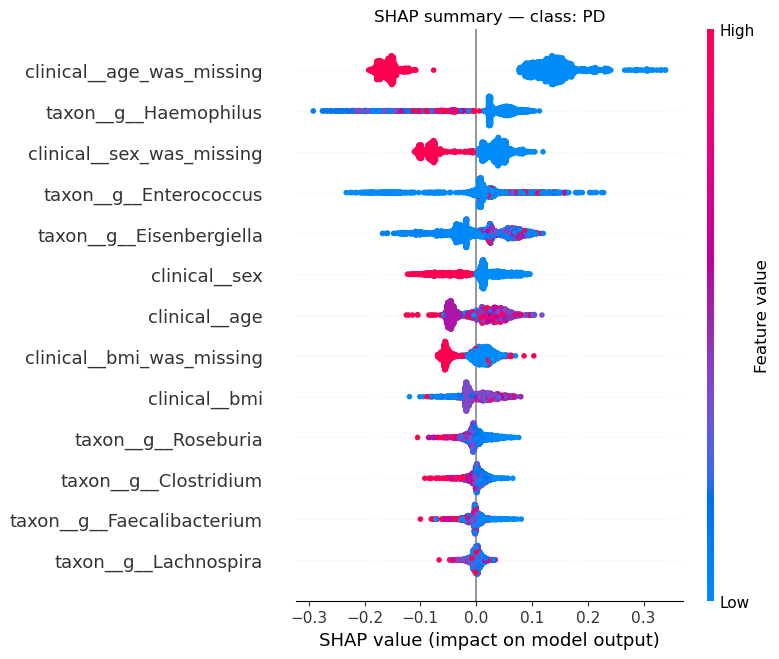

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(**grid.best_params_, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(X_scaled, y)

shap_values = run_shap_analysis(final_model, X_scaled, feature_cols, label_encoder, OUTPUT_DIR,
                                 max_display=30 if len(feature_cols) > 40 else None)


## Step 10 - Save artefacts

In [ ]:
save_artifacts(final_model, scaler, label_encoder, feature_cols, OUTPUT_DIR)


Saved model, scaler, label encoder, and feature list to: ml_config1_all_taxa
